# Data Oversampling with deep_tabular_augmentation

## Introduction

    In this notebook we will use the deep_tabular_augmentation package made y the blogger Lasse Schmidt ( lschmiddey ), to oversample the number of fraud cases from the Credit Card Fraud Detection database, this deep learning package generates Synthetic credit card fraud cases from the existing data in order to correct the imbalance of Non-Fraud vs Fraud cases. 

    As we know, the occurrences of fraud can be very rare given that by the very nature of the crime perpetuators will try to obfuscate the nature of these type of transactions and make them appear to be the most "normal" as possible. ML and DL models that look into this problem need are aimed on finding and identifying the characteristics that these type of transaction have in common and for these models to learn they require large datasets to be accurate.

    Given this the data produces result in very unbalanced databases, and consequently models will have trouble trying to find and correctly detect Fraud transactions, it's for this that having more fraud cases to feed ML and DL models is crucial.

## 1. Data loading

In [30]:
from config import *
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from functools import partial
import mlprepare as mlp
import deep_tabular_augmentation as dta
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS,
                         summarize)
from ISLP import confusion_table


In [31]:
#Opening database

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DATA_PATH = '../data/creditcard.csv'

df = pd.read_csv(DATA_PATH, sep=',')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Data exploration

In [32]:
#Counting numbers of Frauds vs Non-Frauds in th original database  
difference_in_class_occurences = df['Class'].value_counts()[0]-df['Class'].value_counts()[1]
difference_in_class_occurences


Class_count=df['Class'].value_counts()
Class_count

Class
0    284315
1       492
Name: count, dtype: int64

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [34]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


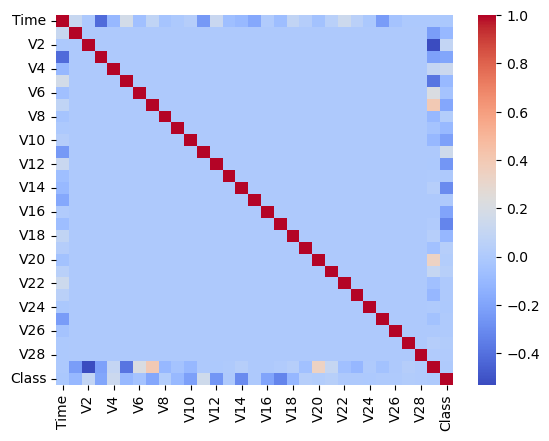

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr()
# Visualize the correlation matrix
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.show()

## 3. Data preparation

### 3.1 Preparing data for the Autoloader model

In [36]:
X_train, X_test, y_train, y_test = mlp.split_df(df, dep_var='Class', test_size=0.3, split_mode='random')

x_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)

X_test_scaled = x_scaler.transform(X_test)

X_train_fraud = X_train_scaled[np.where(y_train==1)[0]]
X_test_fraud = X_test_scaled[np.where(y_test==1)[0]]

In [37]:
datasets = dta.create_datasets(X_train_fraud, y_train.values[np.where(y_train==1)], X_test_fraud, y_test.values[np.where(y_test==1)])
data = dta.DataBunch(*dta.create_loaders(datasets, bs=1024, device='cpu'))

## 4 Model Architecture
### 4.2 Autoencoder 

-     The Autoencoder architecture we used is the one recommended by lschmiddey on his Github repo and blog, in this case a [50, 12, 12].

In [38]:
D_in = X_train_fraud.shape[1]
VAE_arch = [50, 12, 12]  #Autoencoder architecture
target_name = 'Class'    #Target column name where 1 represents frauds and 0 normal transactios
target_class = 1        #Frauds represented by 1
df_cols = list(df.columns)

model = dta.Autoencoder(D_in, VAE_arch, latent_dim=5).to(device)
opt = optim.Adam(model.parameters(), lr=0.01)
loss_func = dta.customLoss()

### 4.3 Learner setting up

-     The following learner will help us determine the best learning rate for our model

In [39]:
learn = dta.Learner(model, opt, loss_func, data, target_name, target_class, df_cols)

run = dta.Runner(cb_funcs=[dta.LR_Find, dta.Recorder])

run.fit(100, learn)

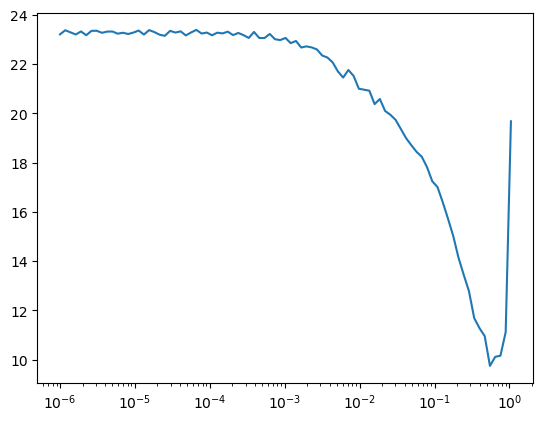

In [40]:
run.recorder.plot(skip_last=5)

In [41]:
sched = dta.combine_scheds([0.3, 0.7], [dta.sched_cos(0.01, 0.1), dta.sched_cos(0.1, 0.01)])

## 5. Model Fit

In [42]:
cbfs = [partial(dta.LossTracker, show_every=50), dta.Recorder, partial(dta.ParamScheduler, 'lr', sched)]
model = dta.Autoencoder(D_in, VAE_arch, latent_dim=20).to(device)
opt = optim.Adam(model.parameters(), lr=0.01)
learn = dta.Learner(model, opt, loss_func, data, target_name, target_class, df_cols)
run = dta.Runner(cb_funcs=cbfs)
run.fit(400, learn)

epoch: 50
train loss is: 25.353174209594727
validation loss is: 24.312721252441406
epoch: 100
train loss is: 18.386493682861328
validation loss is: 17.291763305664062
epoch: 150
train loss is: 14.079319953918457
validation loss is: 24.928342819213867
epoch: 200
train loss is: 11.03777027130127
validation loss is: 22.80604362487793
epoch: 250
train loss is: 9.342970848083496
validation loss is: 18.76766586303711
epoch: 300
train loss is: 8.310077667236328
validation loss is: 16.06171989440918
epoch: 350
train loss is: 7.599369525909424
validation loss is: 14.18765926361084
epoch: 400
train loss is: 7.08043909072876
validation loss is: 12.81169605255127


### 5.1 Loss tracker

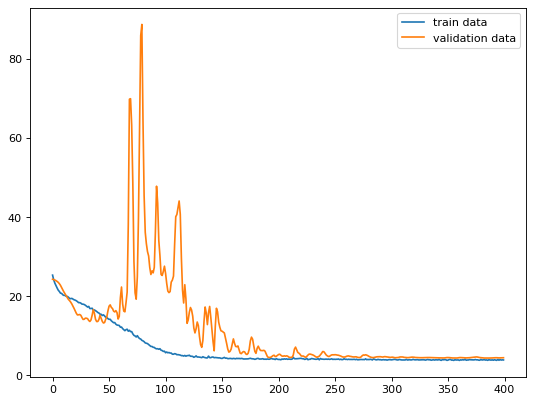

In [43]:
run.loss_tracker.plot_train_vs_val_loss()

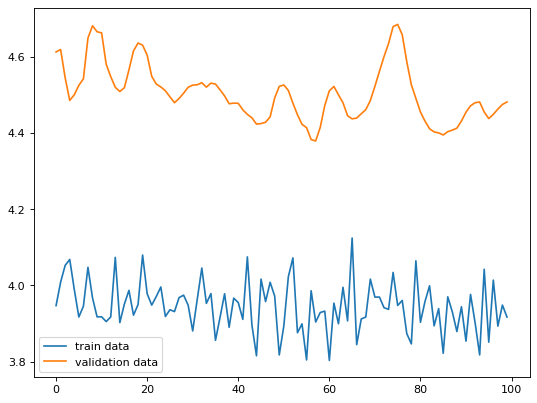

In [44]:
run.loss_tracker.plot_train_vs_val_loss_last_epochs(show_last=100)

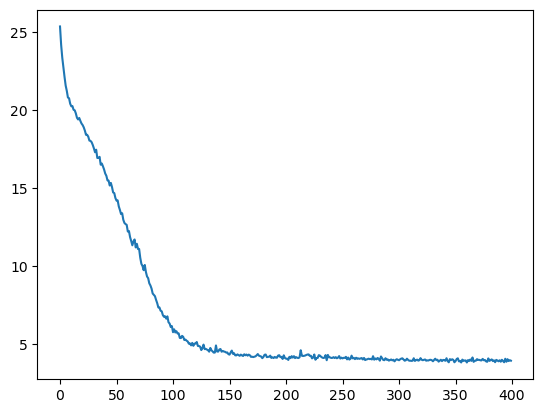

In [45]:
run.recorder.plot_loss()

### 5.2 Learning Rate

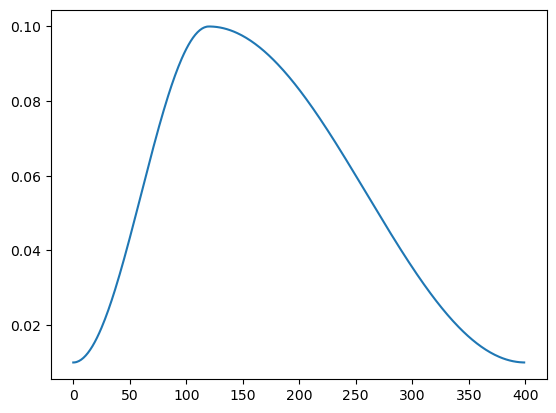

In [46]:
run.recorder.plot_lr()

## 6 Augmented Data
### 6.1 Augmented data with noise

-     In order to make the Augmented data more "real" some level of randomness needs to be implemented, otherwise the data will just be a replica of the "real" frauds and the model will only be learning from copies of the same data. This method is also used on Deep Learning models for image classification, on those models the images generated are similar but slightly different, for example: flipping horizontally or vertically, blurring, rotation, random cropping etc. For tubular data the concept is the same, here the  deep_tabular_augmentation package does the same generating statistically similar fraud data.  

In [47]:
# difference_in_class_occurences = 1000
df_fake = run.predict_df(learn, no_samples=difference_in_class_occurences, scaler=x_scaler)
std_list = list(df[df['Class']==1][df_cols].std()/10)
df_fake_with_noise = run.predict_with_noise_df(learn, no_samples=difference_in_class_occurences, mu=0, sigma=std_list, scaler=x_scaler)
df_fake_with_noise.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,80401.552551,-3.893853,2.944645,-4.970264,3.935830,-1.766156,-1.604387,-3.063703,2.319177,-1.951758,...,1.314341,0.052681,0.274598,-0.201882,-0.012953,0.069088,0.407416,0.213578,118.992793,1
1,88138.689624,-2.553897,2.151435,-4.223631,4.196992,-0.394815,-1.369275,-3.925314,0.865402,-2.022506,...,0.637026,0.017972,0.125339,-0.187272,-0.034205,0.136681,0.280085,0.169247,85.465211,1
2,87326.481971,-1.135292,1.676598,-4.757783,3.572065,-0.016217,-1.171201,-1.207165,0.676181,-1.737498,...,0.822219,-0.225004,-0.157752,-0.176848,0.024221,0.077609,-0.025526,0.174335,116.763633,1
3,87831.480991,-2.427890,2.733694,-4.542629,3.825806,-2.236023,-1.605849,-2.257902,-0.173560,-2.170964,...,0.408154,0.127370,-0.257840,-0.179253,0.025528,0.053396,-0.047425,0.301932,111.132403,1
4,99018.844501,-4.196936,2.277316,-4.675616,3.756738,-1.449566,-1.906452,-2.934763,1.258877,-2.389880,...,0.993426,0.012611,0.033264,-0.213030,-0.191922,0.190807,-0.075779,0.197396,79.241066,1


### 6.2 Data exploration

In [48]:
df_fake_with_noise.describe().loc[['mean']]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
mean,90637.153313,-2.512458,2.437812,-4.790662,3.817506,-1.274226,-1.459701,-3.03109,0.518539,-2.036059,...,0.896591,0.005771,-0.039394,-0.170767,-0.032603,0.120866,0.199325,0.219909,115.500863,1.0


In [49]:
df_fake.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,...,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.0
mean,90647.046875,-2.512017,2.438239,-4.791440,3.817454,-1.273792,-1.459747,-3.033037,0.516739,-2.036025,...,0.897760,0.005372,-0.038787,-0.170694,-0.032942,0.121013,0.199002,0.220059,115.548080,1.0
std,5121.899414,0.783912,0.441954,0.751363,0.348557,0.732232,0.143285,0.893834,0.581778,0.345597,...,0.252938,0.091281,0.049231,0.018888,0.051295,0.016045,0.067989,0.016548,7.839664,0.0
min,36856.007812,-13.024666,0.886719,-16.088255,2.610220,-11.245857,-3.571878,-18.530575,-36.221828,-5.628696,...,0.226316,-8.698697,-0.490797,-0.619283,-0.174336,-0.108902,-1.560898,-0.593223,0.587241,1.0
25%,91439.292969,-2.837249,2.149843,-5.218816,3.614254,-1.507915,-1.563922,-3.371850,0.223329,-2.126735,...,0.825372,-0.022576,-0.050762,-0.165598,-0.061647,0.113332,0.153392,0.214187,111.907753,1.0
50%,92495.609375,-2.322113,2.377091,-4.671440,3.720641,-1.086593,-1.463820,-2.842002,0.378402,-1.946327,...,0.909703,-0.012697,-0.037672,-0.162995,-0.050293,0.123003,0.185634,0.221662,116.337296,1.0
75%,93059.886719,-1.999910,2.663408,-4.289587,3.904901,-0.818088,-1.379650,-2.473283,0.683246,-1.833085,...,0.949090,0.026347,-0.032952,-0.162333,-0.033018,0.132687,0.226926,0.226752,120.549332,1.0
max,93397.531250,-0.308495,12.585596,-1.856489,8.574510,0.752088,5.519263,-0.046672,6.634198,-0.405510,...,26.780243,0.639383,5.147978,0.596400,0.298735,0.521970,2.432986,1.111990,154.167389,1.0


In [50]:
df_fake_with_noise.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,...,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.000000,283823.0
mean,90637.153313,-2.512458,2.437812,-4.790662,3.817506,-1.274226,-1.459701,-3.031090,0.518539,-2.036059,...,0.896591,0.005771,-0.039394,-0.170767,-0.032603,0.120866,0.199325,0.219909,115.500863,1.0
std,7026.060727,1.035686,0.616937,1.037638,0.453126,0.909473,0.234118,1.149273,0.886008,0.427248,...,0.451014,0.171857,0.164341,0.054973,0.094905,0.049926,0.153498,0.057221,26.903120,0.0
min,31185.266019,-12.466877,-0.269576,-18.570140,1.858648,-10.828971,-3.689605,-17.337971,-31.881518,-5.920834,...,-1.055868,-8.034745,-0.819194,-0.599736,-0.436729,-0.185085,-0.996186,-0.691296,0.775710,1.0
25%,87509.672076,-3.126631,2.019415,-5.449752,3.518132,-1.750799,-1.610869,-3.681595,-0.045968,-2.247044,...,0.622761,-0.099245,-0.147028,-0.207145,-0.096511,0.087870,0.096318,0.182018,97.344731,1.0
50%,91550.173577,-2.419677,2.409336,-4.743434,3.766282,-1.165572,-1.462480,-2.922421,0.480516,-1.982811,...,0.892822,0.005771,-0.039988,-0.170236,-0.038013,0.121328,0.196801,0.219626,115.577375,1.0
75%,95143.449459,-1.800933,2.825558,-4.081030,4.050053,-0.663367,-1.311605,-2.257636,1.044437,-1.756370,...,1.164299,0.112126,0.067651,-0.133906,0.024370,0.154504,0.298425,0.257273,133.672362,1.0
max,113841.539792,1.538105,11.423326,-0.485779,9.106624,2.171002,4.686962,1.760572,7.697122,-0.267464,...,23.330429,0.835164,4.905706,0.565837,0.457490,0.509427,2.321631,1.193097,239.037399,1.0


In [51]:
from collections import defaultdict
total = df_fake_with_noise['Class'].value_counts() #This df is full of the synthetic fraud cases
total

Class
1    283823
Name: count, dtype: int64

### 6.3 Fraud vs Augmented Fraud data visualization

-     The inferior left plot represents the Augmented Fraud Cases and as we can see graphically they rassemble the shape of the Real Fraud Cases

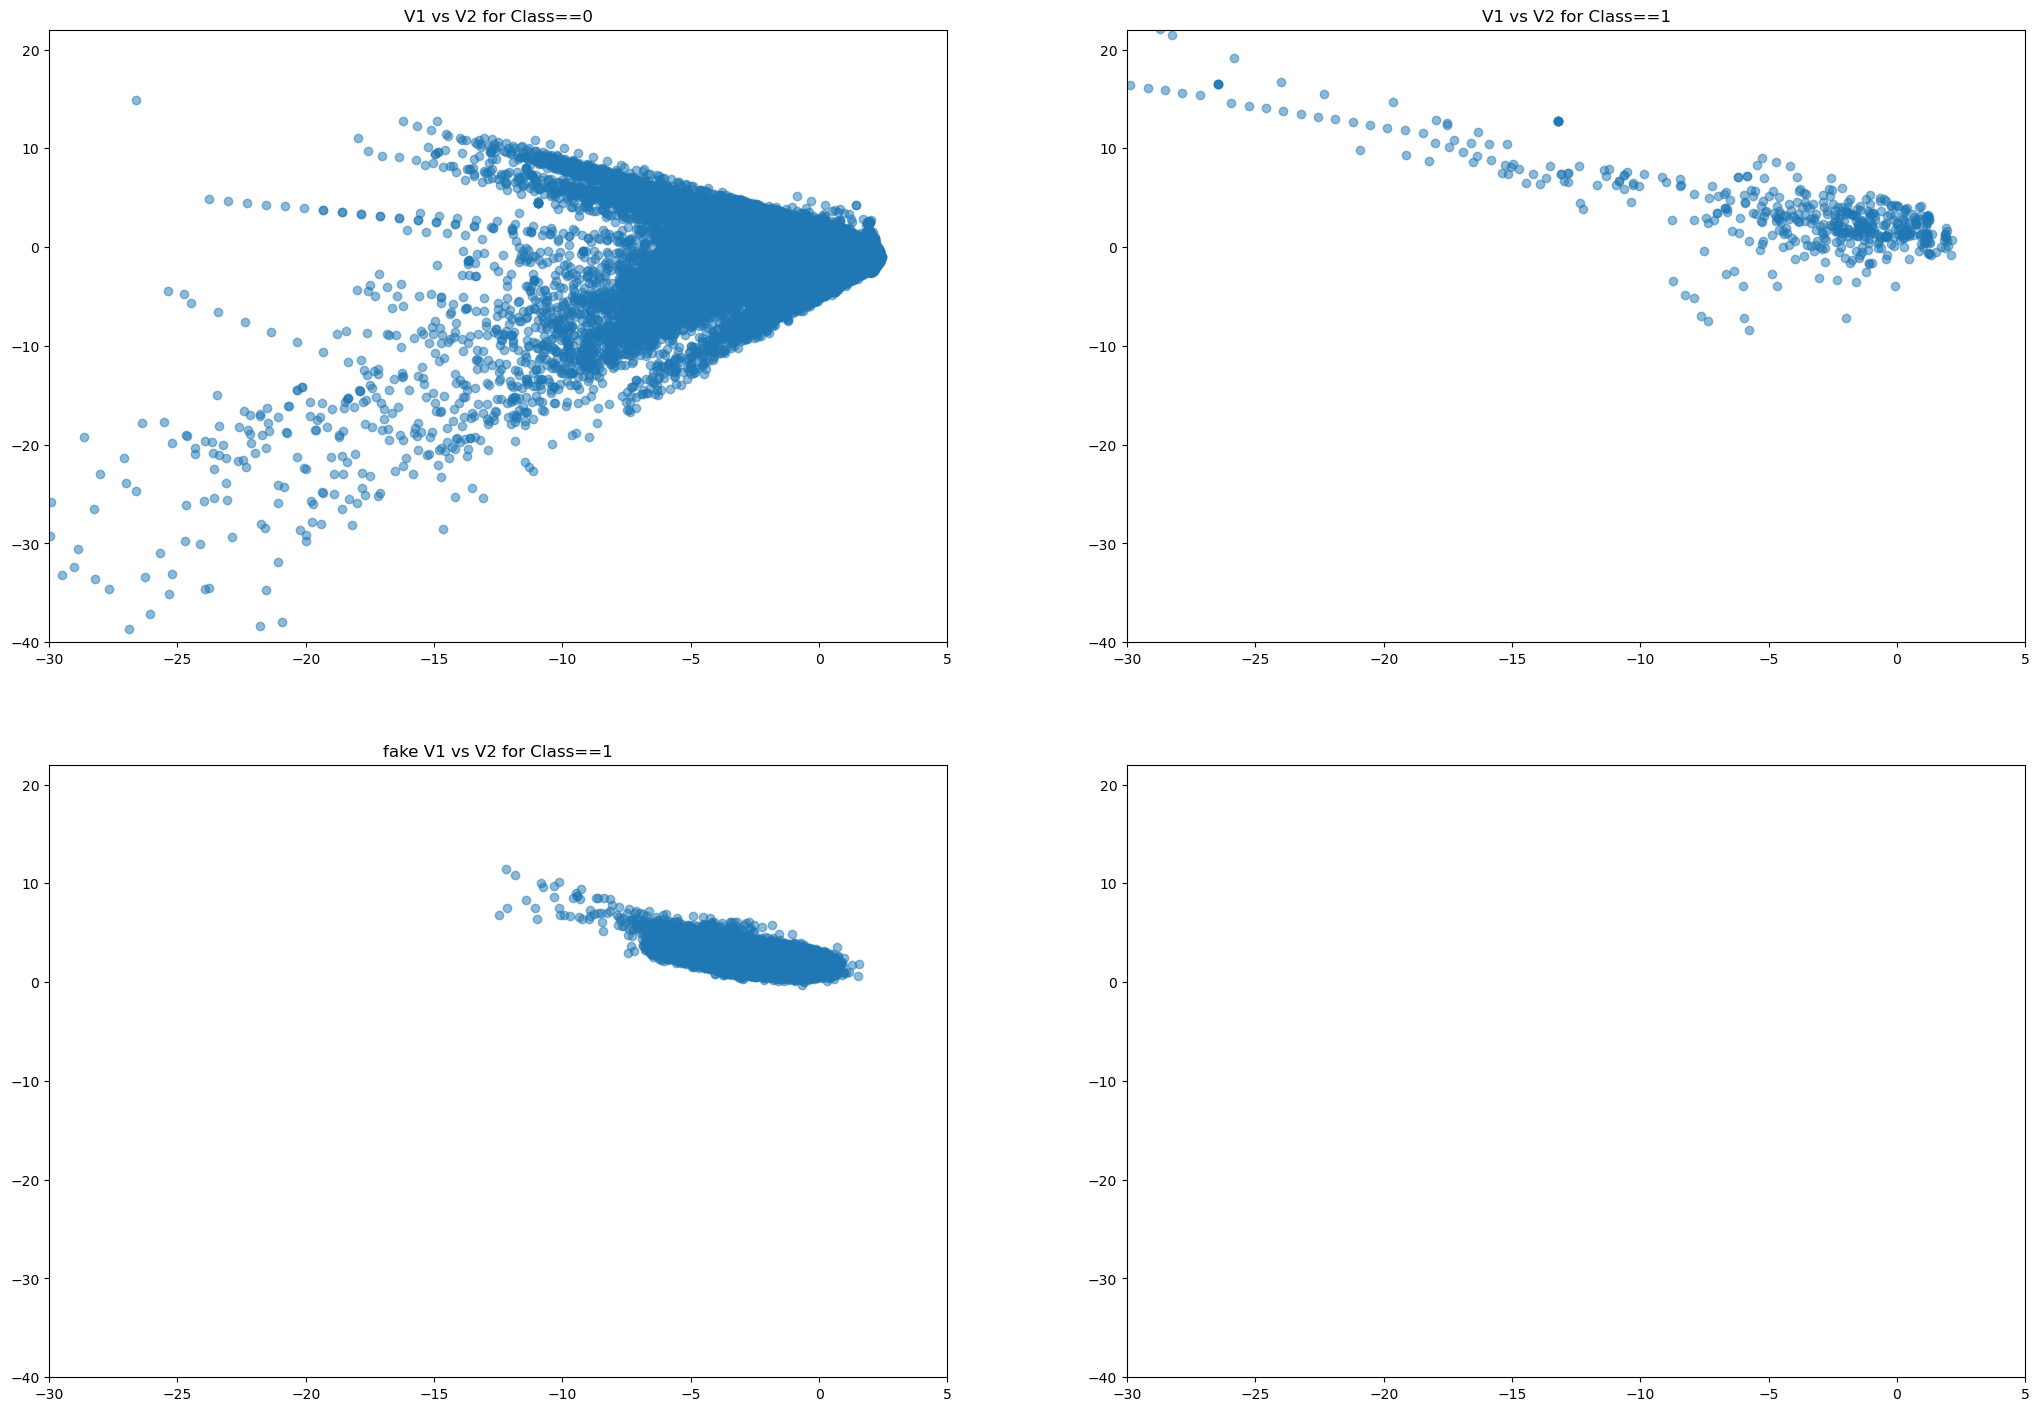

In [52]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 2)
# Defining custom 'xlim' and 'ylim' values.
custom_xlim = (-30, 5)
custom_ylim = (-40, 22)
# Setting the values for all axes.
plt.setp(axs, xlim=custom_xlim, ylim=custom_ylim)
fig.set_size_inches(25.5, 17.5)
axs[0, 0].scatter(df[df['Class']==0]['V1'].values, df[df['Class']==0]['V2'].values, alpha=0.5)
axs[0, 0].set_title('V1 vs V2 for Class==0')
axs[0, 1].scatter(df[df['Class']==1]['V1'].values, df[df['Class']==1]['V2'].values, alpha=0.5)
axs[0, 1].set_title('V1 vs V2 for Class==1')
axs[1, 0].scatter(df_fake_with_noise[df_fake_with_noise['Class']==1]['V1'].values, df_fake_with_noise[df_fake_with_noise['Class']==1]['V2'].values, alpha=0.5)
axs[1, 0].set_title('fake V1 vs V2 for Class==1')
plt.show()

## 7 Augmented data on Logistic Regression
### 7.1 Data preparation 

-     Before applying the Logistic Regression we need to add the synthetic fraud cases to our data, and we can see now that on the DataFrame X_train_Augmented_with_noise the Fraud cases now are oversampled and are more than the Non-fraud Cases

In [53]:
#Making 3 Datasets
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets

train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)#Original Set
x_train_Augmented = pd.concat([train_df, df_fake]) #Set with training data Original Data + Generated data
X_train_Augmented_with_noise = pd.concat([train_df, df_fake_with_noise]) #Set with Original Data + Generated data withh Noise

X_train_Augmented_with_noise['Class'].value_counts()  #Now we see the oversampling of the Fraud cases compared to the regular transactions

Class
1    284179
0    199008
Name: count, dtype: int64

In [54]:
# Split the data into training and testing sets
X_train, X_test, X_train_aug = train_df.iloc[:,:30].values, test_df.iloc[:,:30].values, X_train_Augmented_with_noise.iloc[:,:30].values
y_train, y_test, y_train_aug = train_df.iloc[:,30].values, test_df.iloc[:,30].values, X_train_Augmented_with_noise.iloc[:,30].values

### 7.2 Model fit 

In [55]:
#Applying a Logistic Regression model to the datasets
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


# Standardize the feature columns
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train_aug = scaler.fit_transform(X_train_aug)
X_test = scaler.transform(X_test)

# Create a logistic regression model
model = LogisticRegression()
model2 = LogisticRegression()


# Train the model
model.fit(X_train, y_train)          #Model with original data
model2.fit(X_train_aug, y_train_aug) #Model with augmented data


# Make predictions on the test set
y_pred = model.predict(X_test)        #Model predicition with original data
y_pred2 = model2.predict(X_test)       #Model Prediction with augmented data 



### 7.3  Confusion Matrix
#### 7.3.1 Orginal data

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 0.9985487400957364
[[85306     1]
 [  123    13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.93      0.10      0.17       136

    accuracy                           1.00     85443
   macro avg       0.96      0.55      0.59     85443
weighted avg       1.00      1.00      1.00     85443



-     The confusion matrix below shows that the model with the original data fails on accurately predicting fraud cases, the ratio of fraud cases not detected is of around 10 for every fraud case correctly detected (~123 / 13). 

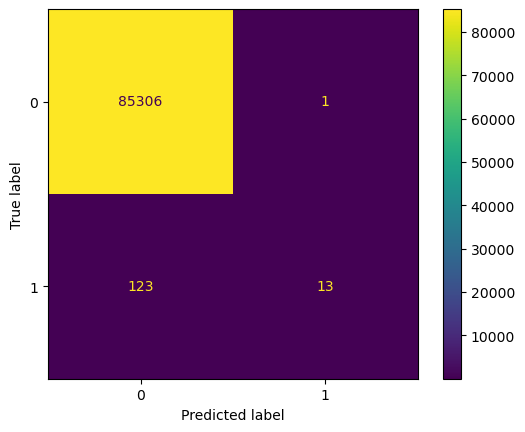

In [57]:
#Displaying confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix) 
disp.plot() 
plt.show()

#### 7.3.2 Augmented data + noise

-     We can see that the Logistic regression model performed better with the Synthetic Fraud Data and detected close to 9x more True Positives on the Test data than without the Synthetic Data, on the other side the Fraud cases non detected reduced to around 1/5 of the original amount. 


In [58]:
# Evaluate the model2
accuracy = accuracy_score(y_test, y_pred2)
conf_matrix = confusion_matrix(y_test, y_pred2)
class_report = classification_report(y_test, y_pred2)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(class_report)

Accuracy: 0.9993562960102056
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.78      0.84      0.81       136

    accuracy                           1.00     85443
   macro avg       0.89      0.92      0.90     85443
weighted avg       1.00      1.00      1.00     85443



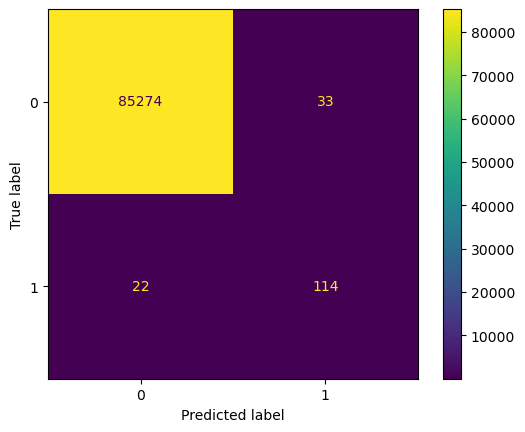

In [68]:
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix) 
disp.plot() 
plt.show()